**Problem 1 (40 pontos)**

CSMA/CD (Carrier Sense Multiple-Access/Collision Detection) is a 
broadcast communication protocol used in local area networks. In a CSMA/CD network, a node that needs to transmit first checks the network traffic. If any traffic is detected, no message is sent (as this would cause a message error), and the medium is only retested in the next clock cycle. Conversely, if no traffic is observed, the message is sent, starting in the following clock cycle. Thus, it is possible for a free medium in one clock cycle to be occupied in the next, resulting in a collision. This behavior makes the message unreadable, and both must attempt to retransmit after waiting a random period of time. 

Suppose it is known that the probability that if the medium is free at time k, it will also be free at time $k + 1$ is 0.9, and that the probability that a medium occupied at time $k$ is also occupied at time $k + 1$ is 0.8.

a) Obtain the state transition diagram and matrix.

**Transition Diagram - Two-State Markov Chain (F = free, O = occupied)**

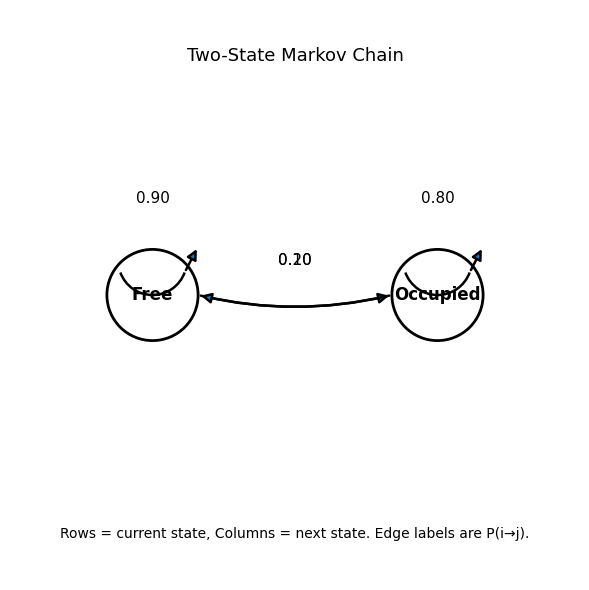

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch, Arc

def draw_markov_2x2(P, labels=('F','O')):
    P = np.asarray(P, dtype=float)
    assert P.shape == (2,2), "P must be 2x2"
    pos = {labels[0]: (0.25, 0.5), labels[1]: (0.75, 0.5)}

    fig = plt.figure(figsize=(12, 6))
    ax = plt.gca(); ax.set_aspect('equal'); ax.axis('off')
    radius = 0.08

    # nodes
    for s in labels:
        x, y = pos[s]
        ax.add_patch(Circle((x, y), radius=radius, fill=False, linewidth=2))
        ax.text(x, y, s, ha='center', va='center', fontsize=12, fontweight='bold')

    def arrow(a, b, p, curvature=0.12):
        (x1,y1), (x2,y2) = pos[a], pos[b]
        dx, dy = x2-x1, y2-y1
        d = (dx*dx+dy*dy)**0.5
        ux, uy = dx/d, dy/d
        start = (x1 + ux*radius, y1 + uy*radius)
        end   = (x2 - ux*radius, y2 - uy*radius)
        ax.add_patch(FancyArrowPatch(start, end, connectionstyle=f"arc3,rad={curvature}",
                                     arrowstyle='-|>', mutation_scale=15, linewidth=1.8))
        mx = (start[0]+end[0])/2 + (-uy)*0.06*np.sign(curvature)
        my = (start[1]+end[1])/2 + (ux)*0.06*np.sign(curvature)
        ax.text(mx, my, f"{p:.2f}", ha='center', va='center', fontsize=11)

    def self_loop(s, p):
        x, y = pos[s]; R = 0.12
        ax.add_patch(Arc((x, y + R/2), width=R, height=R, angle=0,
                         theta1=200, theta2=340, linewidth=1.8))
        head = FancyArrowPatch((x + R/2*np.cos(np.deg2rad(340)), y + R/2 + R/2*np.sin(np.deg2rad(340))),
                               (x + radius*np.cos(0), y + radius + 0.005),
                               connectionstyle="arc3,rad=0.0", arrowstyle='-|>',
                               mutation_scale=15, linewidth=1.8)
        ax.add_patch(head)
        ax.text(x, y + R + 0.05, f"{p:.2f}", ha='center', va='center', fontsize=11)

    # edges
    self_loop(labels[0], P[0,0])
    arrow(labels[0], labels[1], P[0,1])
    self_loop(labels[1], P[1,1])
    arrow(labels[1], labels[0], P[1,0], curvature=-0.12)

    ax.text(0.5, 0.92, "Two-State Markov Chain", ha='center', va='center', fontsize=13)
    ax.text(0.5, 0.08, "Rows = current state, Columns = next state. Edge labels are P(i→j).",
            ha='center', va='center', fontsize=10)

    plt.tight_layout()
    plt.show()
    return plt.show()

# transition matrix
P = np.array([[0.9, 0.1],
              [0.2, 0.8]])

draw_markov_2x2(P, labels=('Free','Occupied'))


**Transition matrix (in Markdown)**

$$ \mathbf{P}=\left[\begin{array}{ccc} 0.9 & 0.1 \\ 0.2 & 0.8 \end{array}\right] $$

**Transition matrix (in code)**

In [19]:
import numpy as np

P = np.array([[0.9, 0.1],[0.2, 0.8]])
print("P =", P)

P = [[0.9 0.1]
 [0.2 0.8]]


b) Obtain the theoretical steady-state matrix.

c) Simulate this system to obtain the steady states and compare the result obtained with the result from the previous item.

Provide the proper comments on the results.

xxxxxxxxxxxxxxxx

**Problem 2 (60 pontos)**

It is known that a certain car wash receives, on average, 20 cars per hour between 7:00 AM and 10:00 AM. The average drops to 8 cars per hour for the rest of the workday, which ends at 6:00 PM. 

Determine analytically and using simulation:

a) What is the average number of cars washed in a full workday?

In [83]:
# Analytical ----------------------------------------------
# Rates (cars/hour)
rate_morning = 20   # 07:00–10:00 (3 hours)
rate_day     = 8    # 10:00–18:00 (8 hours)

# Durations (hours)
hours_morning = 3
hours_day     = 8

expected_total = hours_morning * rate_morning + hours_day * rate_day

print(f"Analytical method")
print(f"-----------------")
print("a) An average of %.3f cars washed is expected in a full workday."%(expected_total))

Analytical method
-----------------
a) An average of 124.000 cars washed is expected in a full workday.


In [84]:
# Simulation ----------------------------------------------
import numpy as np

# 
rng = np.random.default_rng(7)

# Workday in minutes: from 07:00 to 10:00 (180 min), from 10:00 to 18:00 (480 min)
DAY_TOTAL_MIN = 11 * 60         # 660
BOUNDARY_MIN  = 3 * 60          # 180 (where the rate changes)

# Rates
rate1_per_hour = 20.0           # 07:00–10:00
rate2_per_hour = 8.0            # 10:00–18:00
lam1 = rate1_per_hour / 60.0    # per minute
lam2 = rate2_per_hour / 60.0    # per minute

def simulate_one_day():
    t = 0.0
    arrivals = [0.0]  # start time marker
    while t < DAY_TOTAL_MIN:
        if t < BOUNDARY_MIN:
            lam = lam1
            time_to_boundary = BOUNDARY_MIN - t
        else:
            lam = lam2
            time_to_boundary = DAY_TOTAL_MIN - t

        # draw exponential waiting time with current rate
        # Δ ~ Exp(lam): Δ = -ln(U)/lam
        U = rng.random()
        delta = -np.log(1.0 - U) / lam

        if delta > time_to_boundary:
            # no arrival before this block ends; jump to the boundary and change rate
            t += time_to_boundary
            # do not record an arrival; continue with the new rate block
            continue
        else:
            # arrival occurs within the current block
            t += delta
            if t < DAY_TOTAL_MIN:
                arrivals.append(t)
            else:
                break

    # total arrivals = len(arrivals)-1
    return len(arrivals) - 1

# Simulation and statistics
n_days = 365
totals = np.fromiter((simulate_one_day() for _ in range(n_days)), dtype=int, count=n_days)
simulated_mean = totals.mean()

print(f"Simulation")
print(f"-----------------")
print("a) Following a simulation of 365 dias (a year), the average of %.3f cars washed is expected in a full workday." %(simulated_mean))

Simulation
-----------------
a) Following a simulation of 365 dias (a year), the average of 123.542 cars washed is expected in a full workday.


b) What is the probability that no more than 2 cars enter the car wash between 9:00 AM and 9:30 AM?

In [85]:
# Analytical 
import numpy as np
import math

def poisson(n,t,_lambda):
  pn = (_lambda*t)**n/math.factorial(n)*np.exp(-_lambda*t)
  return pn

# item b
t = 0.5  # half an hour
rate = 20 # rate from 07:00 AM to 10:00 PM (20 cars/hour)
P_le_2 = sum(poisson(k, t, rate) for k in range(3))  # k = 0, 1, 2

# P0 = poisson(n,t,rate)

print(f"Analytical method")
print(f"-----------------")
print("b) The probability of no more than 2 cars enter the car wash between 9:00 AM and 9:30 AM is %.6f."%P_le_2)


Analytical method
-----------------
b) The probability of no more than 2 cars enter the car wash between 9:00 AM and 9:30 AM is 0.002769.


In [86]:
# Simulation ----------------------------------------------
import numpy as np

rng = np.random.default_rng(7)

# Interval: 09:00–09:30 (30 minutes) with constant rate 20 cars/hour
rate_per_hour = 20.0
lam_per_min   = rate_per_hour / 60.0
interval_min  = 30.0

def simulate_interval_count(lam_per_min, duration_min):
    t = 0.0
    count = 0
    while True:
        # Δ ~ Exp(lam): Δ = -ln(U)/lam
        U = rng.random()
        delta = -np.log(1.0 - U) / lam_per_min
        t += delta
        if t <= duration_min:
            count += 1
        else:
            break
    return count

# Simulation
n_trials = 365
counts = np.fromiter(
    (simulate_interval_count(lam_per_min, interval_min) for _ in range(n_trials)),
    dtype=int,
    count=n_trials
)

prob_le_2 = np.mean(counts <= 2)

print(f"Simulation")
print(f"-----------------")
print("b) Following a simulation of 365 dias (a year), the probability of no more than 2 cars enter the car wash between 9:00 AM and 9:30 AM is %.6f."%prob_le_2)


Simulation
-----------------
b) Following a simulation of 365 dias (a year), the probability of no more than 2 cars enter the car wash between 9:00 AM and 9:30 AM is 0.005479.


c) What is the probability that more than 3 cars enter the car wash between 4:00 PM and 5:00 PM?

In [87]:
# Analytical 
import math

def poisson(n, t, rate):
    lam = rate * t
    return (lam**n / math.factorial(n)) * math.exp(-lam)

t = 1.0     # 1 hour
rate = 8    # rate from 10:00 AM to 6:00 PM (8 cars/hour)

P_le_3 = sum(poisson(k, t, rate) for k in range(4))   # k = 0,1,2,3
P_gt_3 = 1.0 - P_le_3

print(f"Analytical method")
print(f"-----------------")
print(f"(c) Probability that more than 3 cars enter the car wash between 4:00 PM and 5:00 PM is {P_gt_3:.6f}")

Analytical method
-----------------
(c) Probability that more than 3 cars enter the car wash between 4:00 PM and 5:00 PM is 0.957620


In [88]:
# Simulation ----------------------------------------------
import numpy as np

rng = np.random.default_rng(7)

# Interval: 16:00–17:00 (60 minutes) at 8 cars/hour
rate_per_hour = 8.0
lam_per_min   = rate_per_hour / 60.0
interval_min  = 60.0

def simulate_interval_count(lam_per_min, duration_min):
    """Simulate arrivals in a Poisson process over a fixed-duration interval
       using exponential interarrival times. Returns the count."""
    t = 0.0
    count = 0
    while True:
        # Exponential interarrival with rate lam_per_min
        delta = -np.log(1.0 - rng.random()) / lam_per_min
        t += delta
        if t <= duration_min:
            count += 1
        else:
            break
    return count

# Monte Carlo
n_trials = 365
counts = np.fromiter(
    (simulate_interval_count(lam_per_min, interval_min) for _ in range(n_trials)),
    dtype=int,
    count=n_trials
)

prob_gt_3 = np.mean(counts > 3)

print(f"Simulation")
print(f"-----------------")
print(f"(c) Following a simulation of 365 dias (a year), the probability that more than 3 cars enter the car wash between 4:00 PM and 5:00 PM is {prob_gt_3:.6f}")




Simulation
-----------------
(c) Following a simulation of 365 dias (a year), the probability that more than 3 cars enter the car wash between 4:00 PM and 5:00 PM is 0.953425


d) What is the probability of having exactly 2 cars between 9:55 AM and 10:10 AM?

In [89]:
import math

def poisson(n, t, rate):
    lam = rate * t
    return (lam**n / math.factorial(n)) * math.exp(-lam)

# (d) Probability of having exactly 2 cars between 9:55 AM and 10:10 AM
# Split it into two parts
# part 1: 09:55–10:00  -> 5 minutes at 20 cars/hour
# part 2: 10:00–10:10  -> 10 minutes at 8 cars/hour

# part 1: 5 minutes = 5/60 hours, rate = 20
t1 = 5 / 60
rate1 = 20.0

# part 2: 10 minutes = 10/60 hours, rate = 8
t2 = 10 / 60
rate2 = 8.0

# Poisson probabilities for each part
# We want: N_total = N1 + N2 = 2
# So we sum over all splits: (0,2), (1,1), (2,0)
p1_0 = poisson(0, t1, rate1)
p1_1 = poisson(1, t1, rate1)
p1_2 = poisson(2, t1, rate1)

p2_0 = poisson(0, t2, rate2)
p2_1 = poisson(1, t2, rate2)
p2_2 = poisson(2, t2, rate2)

P_total_2 = (
    p1_0 * p2_2 +  # 0 in the first, 2 in the second
    p1_1 * p2_1 +  # 1 in the first, 1 in the second
    p1_2 * p2_0    # 2 in the first, 0 in the second
)

print(f"Analytical method")
print(f"-----------------")
print(f"(d) Probability of having exactly 2 cars between 9:55 AM and 10:10 AM: {P_total_2:.6f}")


Analytical method
-----------------
(d) Probability of having exactly 2 cars between 9:55 AM and 10:10 AM: 0.224042


In [90]:
# Simulation ----------------------------------------------
import numpy as np

rng = np.random.default_rng(7)

# Segment 1: 09:55–10:00 -> 5 minutes at 20 cars/hour
rate1_per_hour = 20.0
lam1_per_min   = rate1_per_hour / 60.0
dur1_min       = 5.0

# Segment 2: 10:00–10:10 -> 10 minutes at 8 cars/hour
rate2_per_hour = 8.0
lam2_per_min   = rate2_per_hour / 60.0
dur2_min       = 10.0

def simulate_interval_count(lam_per_min, duration_min):
    t = 0.0
    count = 0
    while True:
        # Δ ~ Exp(lam): Δ = -ln(U)/lam
        delta = -np.log(1.0 - rng.random()) / lam_per_min
        t += delta
        if t <= duration_min:
            count += 1
        else:
            break
    return count

# simulation
n_trials = 365
counts1 = np.fromiter(
    (simulate_interval_count(lam1_per_min, dur1_min) for _ in range(n_trials)),
    dtype=int,
    count=n_trials
)
counts2 = np.fromiter(
    (simulate_interval_count(lam2_per_min, dur2_min) for _ in range(n_trials)),
    dtype=int,
    count=n_trials
)

total_counts = counts1 + counts2
prob_eq_2 = np.mean(total_counts == 2)

print(f"Simulation")
print(f"-----------------")
print(f"(d) Following a simulation of 365 dias (a year), the probability of having exactly 2 cars between 9:55 AM and 10:10 AM: {prob_eq_2:.6f}")

Simulation
-----------------
(d) Following a simulation of 365 dias (a year), the probability of having exactly 2 cars between 9:55 AM and 10:10 AM: 0.221918


Provide the proper comments on the results

xxxxxxxxxxxxxxxxxxxx